# Ropedia Academy — A5 · Hand & face models (MANO, FLAME)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/A5.ipynb)

> **Composes MANO + FLAME + body into SMPL-X via one shared recipe and renders the parts in 3D with the object contact point.**
>
> 用同一套配方把 MANO + FLAME + 身体组合成 SMPL-X，并在 3D 中渲染各部位与物体接触点。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/A5

SMPL-X verts: 540 | hand-object contact dist: 1.016


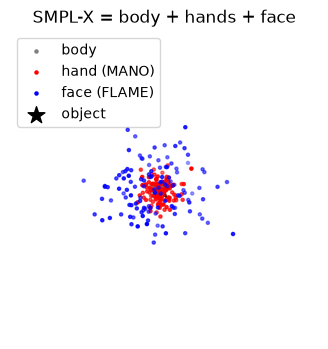

In [1]:
import torch, matplotlib.pyplot as plt
# One parametric recipe -> body / hand (MANO) / face (FLAME) -> SMPL-X.

# ---------- INPUT: per-part templates + shape/pose parameters ----------
mk = lambda Vn, nb: (torch.randn(Vn,3)*0.3, torch.randn(Vn,3,nb))
hand_tpl, hand_dirs = mk(120, 10)               # MANO bases
face_tpl, face_dirs = mk(120, 50)               # FLAME bases
body = torch.randn(300, 3) * 0.6
obj  = torch.tensor([1.3, 0.1, 0.0])            # an object to test contact

# ---------- MODEL: shared identity-blendshape + articulation recipe ----------
def parametric_model(beta, pose, template, shape_dirs):
    v = template + shape_dirs @ beta            # identity / shape
    a = pose[0]; c, s = torch.cos(a), torch.sin(a)
    R = torch.tensor([[c,-s,0],[s,c,0],[0,0,1.]])
    return v @ R.T                               # articulate
hand = parametric_model(torch.randn(10), torch.randn(3), hand_tpl, hand_dirs) + torch.tensor([1.,0,0])
face = parametric_model(torch.randn(50), torch.randn(3), face_tpl, face_dirs) + torch.tensor([-1.,1,0])
smplx = torch.cat([body, hand, face], 0)        # SMPL-X = body + hands + face

# ---------- OUTPUT: vertex count, contact distance, and the composed 3D model ----------
print("SMPL-X verts:", smplx.shape[0], "| hand-object contact dist:",
      round((hand - obj).norm(dim=1).min().item(), 3))
fig = plt.figure(figsize=(5, 4)); ax = fig.add_subplot(projection='3d')
for m, c, l in [(body,'gray','body'),(hand,'r','hand (MANO)'),(face,'b','face (FLAME)')]:
    m = m.numpy(); ax.scatter(m[:,0], m[:,2], m[:,1], s=5, c=c, label=l)
ax.scatter(obj[0], obj[2], obj[1], c='k', marker='*', s=160, label='object')
ax.legend(); ax.set_axis_off(); plt.title("SMPL-X = body + hands + face"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/A5
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks